In [2]:
%pip install torch_geometric

  Using cached torch_geometric-2.7.0-py3-none-any.whl.metadata (63 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached frozenlist-1.8.0-cp312-cp312-win_amd64.whl.metadata (21 kB)
  Using cached multidict-6.7.1-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached charset_normalizer-3.4.6-cp312-cp312-win_amd64.whl.metadata (41 kB)
Using cached torch_geometric-2.7.0-py3-none-any.whl (1.3 MB)
Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl (15 kB)
Using cached aiosignal-1.4.0-py3-none-any.whl (7.5 kB)
Using cached attrs-26.1.0-py3-none-any.whl (67 kB)

   --- ------------------------------------  1/13 [urllib3]
   --- ------------------------------------  1/13 [urllib3]
   --- ------------------------------------  1/13 [urllib3]
   --- ------------------------------------  1/13 [urllib3]
   --- ------------------

imports

In [9]:
import os
import h5py
import torch
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler

from scipy.sparse import csgraph
from scipy.sparse.linalg import eigsh

import torch.nn as nn
import timm

from torch_geometric.data import Data
from torch_geometric.nn import GATConv

In [10]:
def load_pcam_data(path, n_samples=5000):
    with h5py.File(os.path.join(path, 'camelyonpatch_level_2_split_train_x.h5'), 'r') as f:
        X = f['x'][:n_samples]

    with h5py.File(os.path.join(path, 'camelyonpatch_level_2_split_train_y.h5'), 'r') as f:
        y = f['y'][:n_samples]

    y = y.reshape(-1)

    return X, y


X, y = load_pcam_data('pcam', 5000)

print("Data shape:", X.shape, y.shape)

Data shape: (5000, 96, 96, 3) (5000,)


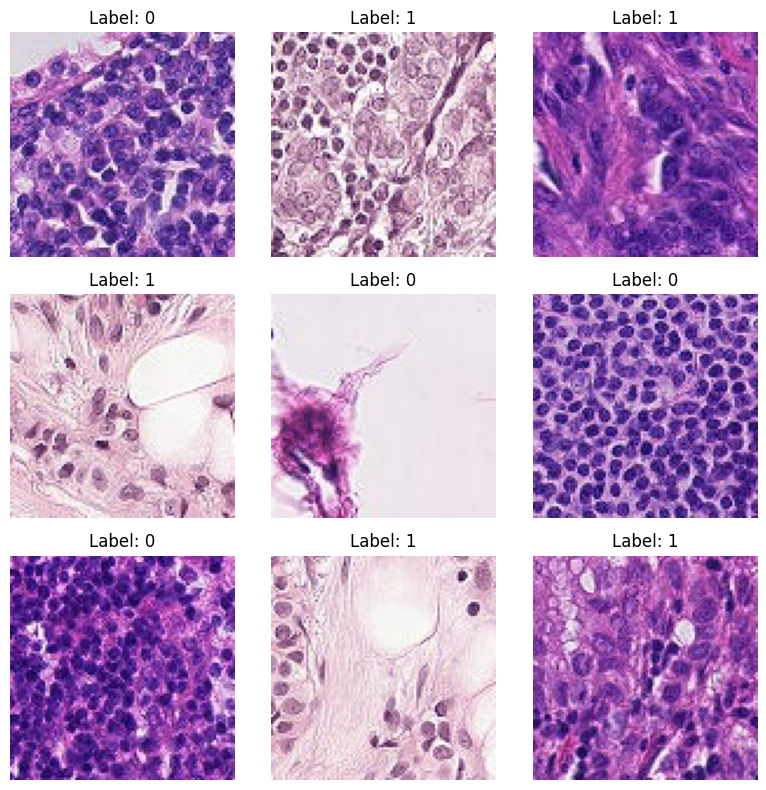

In [11]:
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X[i])
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [12]:
X = X / 255.0
X = torch.tensor(X).permute(0,3,1,2).float()
y = torch.tensor(y).long()

In [13]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

vit = timm.create_model('vit_base_patch16_224', pretrained=True)
vit.head = nn.Identity()
vit = vit.to(device)
vit.eval()

c:\Users\sarah\OncoPRISM\venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sarah\.cache\huggingface\hub\models--timm--vit_base_patch16_224.augreg2_in21k_ft_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [14]:
import torch.nn.functional as F

def resize_batch(x):
    return F.interpolate(x, size=(224,224), mode='bilinear')

In [15]:
features = []

with torch.no_grad():
    for i in tqdm(range(0, len(X), 32)):
        batch = X[i:i+32].to(device)
        batch = resize_batch(batch)

        feat = vit.forward_features(batch)
        feat = feat.mean(dim=1)

        features.append(feat.cpu())

X_feat = torch.cat(features).numpy()

print("Feature shape:", X_feat.shape)

100%|██████████| 157/157 [27:24<00:00, 10.48s/it]

Feature shape: (5000, 768)


In [16]:
k = 10

A = kneighbors_graph(X_feat, k, mode='distance')

sigma = np.mean(A.data)
A.data = np.exp(-(A.data**2) / (sigma**2))

# mutual kNN
A = A.minimum(A.T)

print("Graph built")

Graph built


In [17]:
L = csgraph.laplacian(A, normed=True)

eigvals, eigvecs = eigsh(L, k=16, which='SM')

print("Eigenvectors shape:", eigvecs.shape)

Eigenvectors shape: (5000, 16)


In [18]:
X_aug = np.concatenate([X_feat, eigvecs], axis=1)

scaler = StandardScaler()
X_aug = scaler.fit_transform(X_aug)

X_aug = torch.tensor(X_aug).float()

In [19]:
edge_index = np.vstack(A.nonzero())
edge_index = torch.tensor(edge_index, dtype=torch.long)

data = Data(
    x=X_aug,
    edge_index=edge_index,
    y=y
)

In [ ]:
class GraphTransformer(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_classes):
        super().__init__()

        self.gnn = GATConv(in_dim, hidden_dim, heads=4)
        self.attn = nn.MultiheadAttention(hidden_dim*4, 4, batch_first=True)
        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim*4, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index):
        x = self.gnn(x, edge_index)
        x_attn, _ = self.attn(x.unsqueeze(0), x.unsqueeze(0), x.unsqueeze(0))
        x = x + x_attn.squeeze(0)

        x = self.ffn(x)
        return self.classifier(x)

In [21]:
model = GraphTransformer(X_aug.shape[1], 128, 2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

data = data.to(device)

In [ ]:
losses = []

for epoch in range(20):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out, data.y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

Epoch 0: Loss = 0.7031
Epoch 1: Loss = 0.5069
Epoch 2: Loss = 0.4429
Epoch 3: Loss = 0.3898
Epoch 4: Loss = 0.3616
Epoch 5: Loss = 0.3387
Epoch 6: Loss = 0.3309
Epoch 7: Loss = 0.3166
Epoch 8: Loss = 0.2981
Epoch 9: Loss = 0.2902
Epoch 10: Loss = 0.2904
Epoch 11: Loss = 0.2907
Epoch 12: Loss = 0.2705
Epoch 13: Loss = 0.2612
Epoch 14: Loss = 0.2503
Epoch 15: Loss = 0.2434
Epoch 16: Loss = 0.2312
Epoch 17: Loss = 0.2251
Epoch 18: Loss = 0.2150
Epoch 19: Loss = 0.2051


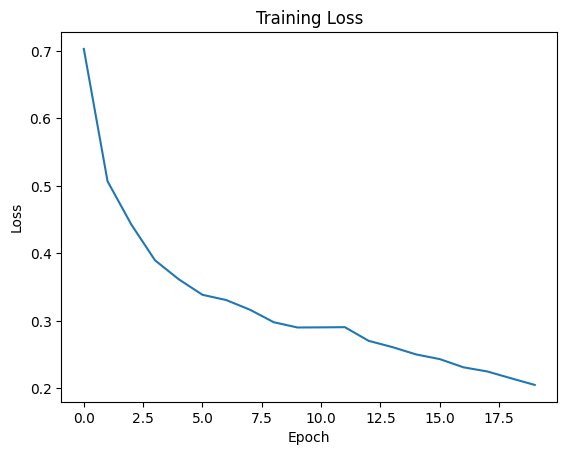

In [23]:
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

model.eval()

with torch.no_grad():
    logits = model(data.x, data.edge_index)

    probs = torch.softmax(logits, dim=1)[:, 1] 
    preds = logits.argmax(dim=1)

y_true = data.y.cpu().numpy()
y_pred = preds.cpu().numpy()
y_prob = probs.cpu().numpy()

In [28]:
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {auc:.4f}")

Accuracy  : 0.9196
Precision : 0.9201
Recall    : 0.9223
F1 Score  : 0.9212
ROC AUC   : 0.9760


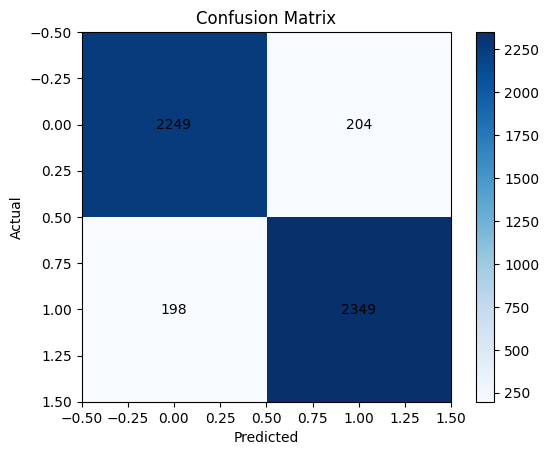

In [29]:
cm = confusion_matrix(y_true, y_pred)

plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

In [30]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      2453
           1       0.92      0.92      0.92      2547

    accuracy                           0.92      5000
   macro avg       0.92      0.92      0.92      5000
weighted avg       0.92      0.92      0.92      5000



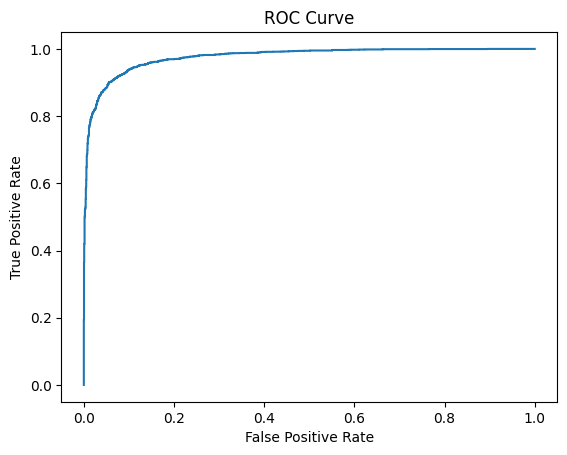

In [31]:
fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

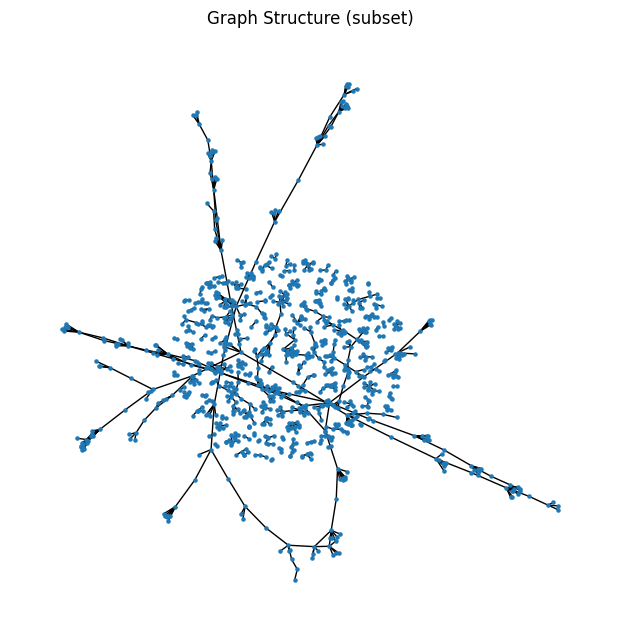

In [25]:
import networkx as nx

G = nx.Graph()
edges = edge_index[:, :1000].numpy()

G.add_edges_from(edges.T)

plt.figure(figsize=(6,6))
nx.draw(G, node_size=5)
plt.title("Graph Structure (subset)")
plt.show()